In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [95]:
image_path = "./assets/tray1.jpg"
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Nie można znaleźć pliku: {image_path}")

# Kopia obrazu dla rysowania i konwersja do RGB (dla Matplotliba)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
# Konwersja do skali szarości i rozmycie w celu redukcji szumów
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (7, 7), 1.5)

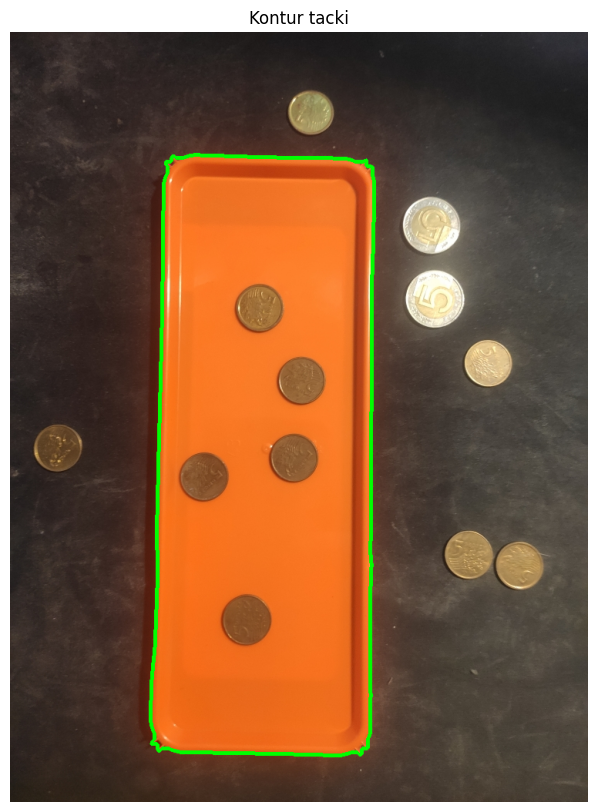

In [96]:
#WYZNACZANIE KONTURU TACKI
#Zastosowanie detekcji krawędzi Canny
edges = cv2.Canny(blurred, 50, 150)

# Operacje morfologiczne, aby połączyć krawędzie tacki
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

# Znalezienie konturów
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Zakładamy, że największy znaleziony kontur to nasza tacka
if contours:
    tray_contour = max(contours, key=cv2.contourArea)
    cv2.drawContours(img_rgb, [tray_contour], -1, (0, 255, 0), 3) # Zielona linia dla tacki
else:
    raise ValueError("Nie znaleziono konturu tacki")

plt.figure(figsize=(12, 10))
plt.imshow(img_rgb)
plt.title("Kontur tacki")
plt.axis("off")
plt.show()

In [97]:
tray_area = cv2.contourArea(tray_contour)
print(f"Obszar tacki: {tray_area:.2f} pikseli kwadratowych")

Obszar tacki: 213276.00 pikseli kwadratowych
